# Scribble Conditioning Comparison

We compare four scribble conditioning strategies under a **neutral prompt**, measuring how well each matches a target distribution of 5 gender classes.

**Conditions**
- `man_scribble` — HED edge map extracted from a generated man portrait
- `woman_scribble` — HED edge map extracted from a generated woman portrait
- `avg_scribble` — weighted pixel average of 5 class HED maps (by target ratio)
- `sdedit_scribble` — man scribble denoised toward a neutral appearance via SDEdit

**Protocol (repeated over `N_RUNS` seeds)**
1. Generate source portraits → extract scribbles → run all four conditions.
2. Record MMD (CLIP space) vs a freshly drawn target distribution.
3. After all runs: for each method pick the **best scribble** (lowest MMD across seeds).
4. From that best scribble generate **2 000 images**, compute final MMD, and compute per-class proportions via 5-way cosine softmax.

## 1. Setup

In [1]:
import sys, os

if 'google.colab' in str(get_ipython()):
    !pip install -q diffusers transformers accelerate controlnet_aux scikit-learn peft

    from huggingface_hub import login
    from google.colab import userdata
    import getpass

    hf_token = userdata.get('HF') if hasattr(userdata, 'get') else None
    login(token=hf_token) if hf_token else login()

    github_token = userdata.get('GITHUB') if hasattr(userdata, 'get') else getpass.getpass('GitHub token: ')
    repo_url  = f'https://{github_token}@github.com/orineo1/conditional-matching-paper.git'
    repo_name = 'conditional-matching-paper'
    branch    = 'compareSDvsNaive'

    if not os.path.exists(repo_name):
        !git clone {repo_url}
    else:
        !cd {repo_name} && git pull
    !cd {repo_name} && git checkout {branch}

    for path in [f'/content/{repo_name}', f'/content/{repo_name}/SD_cond_SD_controlnet']:
        if path not in sys.path:
            sys.path.insert(0, path)

    print(f'Repo ready on branch: {branch}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 26.2 MB/s eta 0:00:00
Cloning into 'conditional-matching-paper'...
remote: Enumerating objects: 5873, done.
remote: Counting objects: 100% (623/623), done.
remote: Compressing objects: 100% (336/336), done.
remote: Total 5873 (delta 388), reused 495 (delta 287), pack-reused 5250 (from 3)
Receiving objects: 100% (5873/5873), 1.19 GiB | 17.72 MiB/s, done.
Resolving deltas: 100% (1527/1527), done.
error: pathspec 'compareSDvsNaive' did not match any file(s) known to git
Repo ready on branch: compareSDvsNaive


## 2. Imports

In [2]:
import copy, json
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

from models        import load_models
from image_utils   import sobel_proxy, build_base_image
from clip_utils    import load_clip_model, encode_images_clip
from generation    import generate_and_store_cs
from metrics       import compute_mmd

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


## 3. Config

In [3]:
# (label, prompt, fraction) — fractions must sum to 1.0
TARGET_PROMPTS = [
    ('Woman',            'superrealistic portrait photograph of a woman, extremely feminine features, studio lighting',                                                                          0.25),
    ('Woman with masculine features',      'a superrealistic portrait photograph of a woman with masculine features, heavy brow ridge, studio lighting',                    0.25),
    ('Man with feminine features',  'a superrealistic portrait photograph of a man with extremely feminine feminine features, soft delicate face, high cheekbones, studio lighting',       0.25),
    ('Man',              'a superrealistic portrait photograph of a man, extremely masculine features, studio lighting',                                                                             0.25),
]
assert abs(sum(r for _, _, r in TARGET_PROMPTS) - 1.0) < 1e-6, 'Fractions must sum to 1'

CLASS_LABELS  = [label  for label, _, _    in TARGET_PROMPTS]
CLASS_PROMPTS = [prompt for _, prompt, _   in TARGET_PROMPTS]
CLASS_FRACS   = [frac   for _, _, frac     in TARGET_PROMPTS]

# Anchor prompts for scribble extraction (man / woman poles)
MAN_PROMPT   = TARGET_PROMPTS[-1][1]   # 'Man'
WOMAN_PROMPT = TARGET_PROMPTS[0][1]    # 'Woman'

N_SOURCE         = 10
N_TARGET         = 2000
N_COND           = 250
N_FINAL          = 2000
N_RUNS           = 10
CONTROLNET_SCALE = 0.5
SDEDIT_START     = 125
N_STEPS          = 250
SDEDIT_CFG       = 7.5
SDEDIT_PROMPT = 'a face scribble sketch, with a range of feminine to masculine features'
NEUTRAL_PROMPT   = 'a superrealistic professional photograph of'

CONDITION_NAMES = ['man_scribble', 'woman_scribble', 'avg_scribble', 'sdedit_scribble']

print('Config OK')
print('Class fractions:')
for label, _, frac in TARGET_PROMPTS:
    print(f'  {label:<20} {frac:.0%}')

Config OK
Class fractions:
  Woman                25%
  Woman with masculine features 25%
  Man with feminine features 25%
  Man                  25%


## 4. Load models

In [4]:
architect, sprinter        = load_models(device)
clip_model, clip_processor = load_clip_model(device)
print('Models loaded.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/2.50G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded.


## 5. Helpers

In [5]:
from controlnet_aux import HEDdetector
hed = HEDdetector.from_pretrained('lllyasviel/Annotators')


def generate_and_store_cs(pipe, prompt, cond_pil, num_samples, batch_size=2, cn_scale=0.5, seed=None):
    """Generate images with ControlNet + collect latents."""
    original_vae_dtype = pipe.vae.dtype
    pipe.vae.to(dtype=torch.float16)
    all_images, all_lats = [], []

    def latents_callback(p, step_index, timestep, cb_kwargs):
        if step_index == p.num_timesteps - 1:
            p._current_latents = cb_kwargs['latents'].detach().cpu().numpy()
        return cb_kwargs

    generator = torch.Generator(device=pipe.device).manual_seed(seed) if seed is not None else None
    for i in range(0, num_samples, batch_size):
        curr = min(batch_size, num_samples - i)
        result = pipe(
            prompt=[prompt] * curr,
            image=[cond_pil] * curr,
            num_inference_steps=2,
            guidance_scale=0.0,
            controlnet_conditioning_scale=cn_scale,
            callback_on_step_end=latents_callback,
            generator=generator,
        )
        all_images.extend(result.images)
        all_lats.append(pipe._current_latents.reshape(curr, -1))
        print(f'  {len(all_images)}/{num_samples}', end='\r')
    print()
    pipe.vae.to(dtype=original_vae_dtype)
    return all_images, np.vstack(all_lats)


def generate_condition(scribble_pil, prompt, n, batch_size=2, seed=None):
    """Generate n images from a scribble with neutral prompt."""
    sprinter.vae.to(dtype=torch.float16)
    generator = torch.Generator(device=sprinter.device).manual_seed(seed) if seed is not None else None
    images = []
    with torch.no_grad():
        for start in range(0, n, batch_size):
            bs = min(batch_size, n - start)
            result = sprinter(
                prompt=[prompt] * bs,
                image=[scribble_pil] * bs,
                num_inference_steps=2,
                guidance_scale=0.0,
                controlnet_conditioning_scale=CONTROLNET_SCALE,
                output_type='pil',
                generator=generator,
            )
            images.extend(result.images)
            print(f'  {len(images)}/{n}', end='\r')
    sprinter.vae.to(dtype=torch.float32)
    print()
    return images


def clip_embed(images):
    """Encode a list of PIL images to CLIP embeddings [N, D]."""
    tensors = torch.cat([TF.to_tensor(img).unsqueeze(0) for img in images]).to(device)
    clip_model.to(device)
    with torch.no_grad():
        embs = encode_images_clip(tensors, clip_model, clip_processor)
    clip_model.to('cpu')
    return embs


def encode_text_prompts(prompts):
    clip_model.to(device)
    inputs = clip_processor(
        text=prompts,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        # use pooler_output directly from the output we already saw
        outputs = clip_model.text_model(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask']
        )
        text_embs = outputs.pooler_output  # [N, D] — this is a plain tensor

    # project through the text projection layer (same as get_text_features does internally)
    text_embs = clip_model.text_projection(text_embs)

    clip_model.to('cpu')
    text_embs = text_embs / text_embs.norm(dim=-1, keepdim=True)
    return text_embs  # [N, D]


def classify_multinomial(image_embs, text_embs):
    """
    5-way cosine softmax classification.
    image_embs: [N, D] (already L2-normalised from encode_images_clip)
    text_embs:  [C, D] (L2-normalised)
    Returns:
        labels  : list of predicted class indices  [N]
        probs   : np.array [N, C]  softmax probabilities
        proportions: np.array [C]  fraction predicted per class
    """
    image_embs_n = F.normalize(image_embs.float(), dim=-1)  # ensure normalised
    logits = image_embs_n @ text_embs.T.float()             # [N, C]  cosine sims
    probs  = torch.softmax(logits * 100, dim=-1).cpu().numpy()  # temp=100 sharpens
    labels = probs.argmax(axis=1).tolist()
    proportions = np.bincount(labels, minlength=len(CLASS_LABELS)) / len(labels)
    return labels, probs, proportions


def build_target(sobel_pil, seed_offset=0, n=N_TARGET):
    """Build target distribution across all 5 classes by their target fractions."""
    all_imgs = []
    for i, (label, prompt, frac) in enumerate(TARGET_PROMPTS):
        n_i = int(n * frac)
        print(f'  [{label}] generating {n_i} images...')
        with torch.no_grad():
            imgs, _ = generate_and_store_cs(
                sprinter, prompt, sobel_pil, n_i, 2, CONTROLNET_SCALE,
                seed=seed_offset + i * 500
            )
        all_imgs.extend(imgs)
    return clip_embed(all_imgs)


def run_sdedit(scr_man_pil, seed):
    """SDEdit: add noise to man scribble then denoise toward neutral prompt."""
    architect.vae.to(dtype=torch.float32)
    architect.scheduler.set_timesteps(N_STEPS, device=device)
    timesteps = architect.scheduler.timesteps

    with torch.no_grad():
        t = TF.to_tensor(scr_man_pil.convert('RGB')).unsqueeze(0).to(device).float()
        t = (t * 2.0) - 1.0
        latent = architect.vae.encode(t).latent_dist.mean * architect.vae.config.scaling_factor

    t_start = timesteps[SDEDIT_START]
    alpha   = architect.scheduler.alphas_cumprod.to(device)[t_start.long()].float()
    gen     = torch.Generator(device=device).manual_seed(seed)
    noise   = torch.randn(latent.shape, generator=gen, device=device, dtype=torch.float32)
    latents = ((alpha ** 0.5) * latent + ((1 - alpha) ** 0.5) * noise).half()

    with torch.no_grad():
        prompt_embeds, neg_embeds, pooled, neg_pooled = architect.encode_prompt(
            prompt=SDEDIT_PROMPT, negative_prompt='', device=device,
            do_classifier_free_guidance=True, num_images_per_prompt=1,
        )
    add_ids = torch.tensor([[512, 512, 0, 0, 512, 512]], dtype=prompt_embeds.dtype, device=device)
    added   = {'text_embeds': torch.cat([neg_pooled, pooled]), 'time_ids': add_ids.repeat(2, 1)}
    cfg_st  = torch.cat([neg_embeds, prompt_embeds])

    sched = copy.deepcopy(architect.scheduler)
    with torch.no_grad():
        for t in timesteps[SDEDIT_START:]:
            lmi  = sched.scale_model_input(torch.cat([latents] * 2), t)
            out  = architect.unet(lmi, t, encoder_hidden_states=cfg_st, added_cond_kwargs=added, return_dict=False)[0]
            nu, nc = out.chunk(2)
            latents = sched.step(nu + SDEDIT_CFG * (nc - nu), t, latents).prev_sample

    with torch.no_grad():
        dec = architect.vae.decode((latents.float() / architect.vae.config.scaling_factor).to(architect.vae.dtype)).sample
        pil = T.ToPILImage()(torch.clamp((dec.float() + 1.0) / 2.0, 0.0, 1.0).squeeze(0).cpu())
    return pil


def multinomial_ci_normal(counts, n_total, z=1.96):
    """
    Normal-approximation 95% CI for each class proportion.
    counts: array [C] of predicted counts per class
    Returns: p_hats [C], ci_lo [C], ci_hi [C]
    """
    p_hats = counts / n_total
    ses    = np.sqrt(p_hats * (1 - p_hats) / n_total)
    return p_hats, p_hats - z * ses, p_hats + z * ses


print('Helpers ready.')

/usr/local/lib/python3.12/dist-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/controlnet_aux/segment_anything/modeling/tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_5m_224 in registry with controlnet_aux.segmen

ControlNetHED.pth:   0%|          | 0.00/29.4M [00:00<?, ?B/s]

Helpers ready.


In [6]:
print(type(clip_model))
print(clip_model.__class__.__name__)

<class 'transformers.models.clip.modeling_clip.CLIPModel'>
CLIPModel


## 6. Base oval & Sobel conditioning

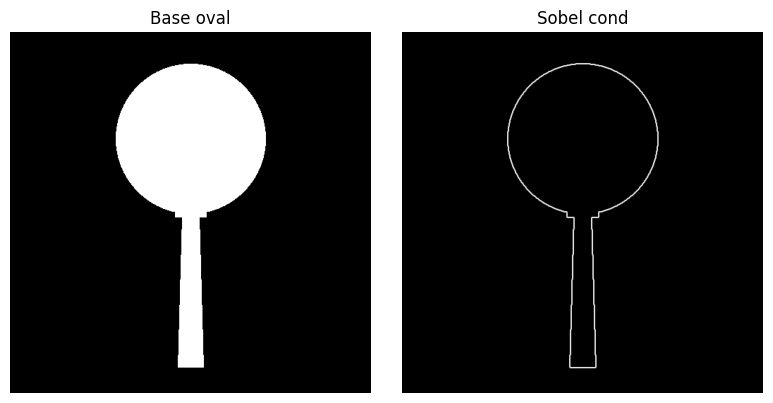

Class text embeddings: torch.Size([4, 768])


In [7]:
base_image_pil, base_tensor = build_base_image(device)
with torch.no_grad():
    sobel_pil = T.ToPILImage()(sobel_proxy(base_tensor, device).squeeze(0).cpu())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(base_image_pil); axes[0].set_title('Base oval');    axes[0].axis('off')
axes[1].imshow(sobel_pil, cmap='gray'); axes[1].set_title('Sobel cond'); axes[1].axis('off')
plt.tight_layout(); display(fig); plt.close()

# Pre-compute text embeddings for all 5 classes (used in classification)
class_text_embs = encode_text_prompts(CLASS_PROMPTS)  # [5, D]
print(f'Class text embeddings: {class_text_embs.shape}')

## 7. Main experiment loop

For each seed: generate one source portrait per class → extract HED scribbles → build weighted avg → run SDEdit → draw proxy target → evaluate all conditions.

In [8]:
SAVE_DIR = '/content/scribble_runs'
os.makedirs(SAVE_DIR, exist_ok=True)

all_records   = []
best_per_method = {c: {'seed': None, 'mmd': float('inf'), 'scribble': None} for c in CONDITION_NAMES}

for seed in range(1, N_RUNS + 1):
    print(f"\n{'='*55}")
    print(f'  SEED {seed}/{N_RUNS}')
    print(f"{'='*55}")

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

    # ── Generate one source portrait per class
    seed_dir = os.path.join(SAVE_DIR, f'seed_{seed:02d}')
    os.makedirs(seed_dir, exist_ok=True)

    class_scribbles = []   # HED scribble per class
    for i, (label, prompt, frac) in enumerate(TARGET_PROMPTS):
        with torch.no_grad():
            imgs, _ = generate_and_store_cs(sprinter, prompt, sobel_pil, 1, 1, CONTROLNET_SCALE, seed=seed + i)
        scr = hed(imgs[0], scribble=True)
        class_scribbles.append(scr)
        scr.save(os.path.join(seed_dir, f'scribble_{label.lower().replace(" ", "_")}.png'))

    # ── Man / woman scribbles (first and last class)
    scr_man   = class_scribbles[-1]   # 'Man'
    scr_woman = class_scribbles[0]    # 'Woman'

    # ── Weighted average scribble (5 classes by target fraction)
    avg_np = sum(
        frac * np.array(scr).astype(np.float32)
        for scr, (_, _, frac) in zip(class_scribbles, TARGET_PROMPTS)
    ).clip(0, 255).astype(np.uint8)
    scr_avg = Image.fromarray(avg_np)

    # ── SDEdit scribble
    scr_sdedit = run_sdedit(scr_man, seed)

    # ── Save condition scribbles
    scr_man.save(   os.path.join(seed_dir, 'scribble_man.png'))
    scr_woman.save( os.path.join(seed_dir, 'scribble_woman.png'))
    scr_avg.save(   os.path.join(seed_dir, 'scribble_avg.png'))
    scr_sdedit.save(os.path.join(seed_dir, 'scribble_sdedit.png'))

    run_conditions = {
        'man_scribble':    scr_man,
        'woman_scribble':  scr_woman,
        'avg_scribble':    scr_avg,
        'sdedit_scribble': scr_sdedit,
    }

    # ── Proxy target (N_COND images, 5-class mixture)
    print('  Building proxy target...')
    proxy_target_clip = build_target(sobel_pil, seed_offset=seed * 1000, n=N_COND)

    # ── Evaluate each condition
    seed_results = {}
    for cond_name, scribble in run_conditions.items():
        print(f'  Generating [{cond_name}]...')
        imgs = generate_condition(scribble, NEUTRAL_PROMPT, N_COND, seed=seed)
        embs = clip_embed(imgs)
        mmd  = compute_mmd(embs, proxy_target_clip.detach()).item()

        # 5-way classification
        labels, probs, proportions = classify_multinomial(embs, class_text_embs)
        prop_str = '  '.join(f'{l}={p:.1%}' for l, p in zip(CLASS_LABELS, proportions))

        record = {
            'seed': seed, 'condition': cond_name, 'mmd': mmd,
            'proportions': proportions.tolist(),
        }
        all_records.append(record)
        seed_results[cond_name] = mmd

        print(f'    MMD={mmd:.5f}  {prop_str}')

        if mmd < best_per_method[cond_name]['mmd']:
            best_per_method[cond_name]['mmd']      = mmd
            best_per_method[cond_name]['seed']     = seed
            best_per_method[cond_name]['scribble'] = scribble.copy()

    with open(os.path.join(seed_dir, 'results.json'), 'w') as f:
        json.dump(seed_results, f, indent=2)

print('\nAll runs complete.')


  SEED 1/10


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/controlnet/pipeline_controlnet_sd_xl.py:928: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  1/1
  1/1
  1/1
  1/1
  Building proxy target...
  [Woman] generating 62 images...
  62/62
  [Woman with masculine features] generating 62 images...
  62/62
  [Man with feminine features] generating 62 images...
  62/62
  [Man] generating 62 images...
  62/62
  Generating [man_scribble]...
  250/250
    MMD=0.61604  Woman=0.4%  Woman with masculine features=0.4%  Man with feminine features=0.4%  Man=98.8%
  Generating [woman_scribble]...
  250/250
    MMD=0.56505  Woman=92.0%  Woman with masculine features=0.4%  Man with feminine features=7.2%  Man=0.4%
  Generating [avg_scribble]...
  250/250
    MMD=0.42026  Woman=74.4%  Woman with masculine features=14.4%  Man with feminine features=2.4%  Man=8.8%
  Generating [sdedit_scribble]...
  250/250
    MMD=0.55639  Woman=2.4%  Woman with masculine features=2.0%  Man with feminine features=1.6%  Man=94.0%

  SEED 2/10
  1/1
  1/1
  1/1
  1/1
  Building proxy target...
  [Woman] generating 62 images...
  62/62
  [Woman with masculine featur

## 8. Save best scribbles

Best scribble summary:
  man_scribble          seed=10  proxy_mmd=0.48419
  woman_scribble        seed=6  proxy_mmd=0.51668
  avg_scribble          seed=1  proxy_mmd=0.42026
  sdedit_scribble       seed=10  proxy_mmd=0.46341


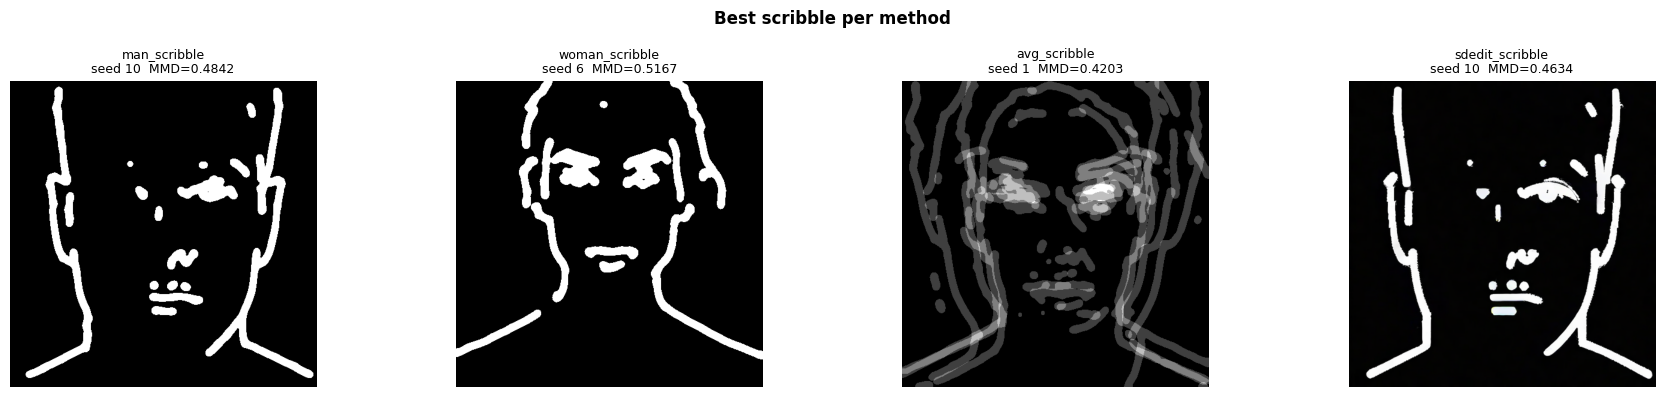

In [9]:
BEST_DIR = os.path.join(SAVE_DIR, 'best_scribbles')
os.makedirs(BEST_DIR, exist_ok=True)

print('Best scribble summary:')
for cond, info in best_per_method.items():
    path = os.path.join(BEST_DIR, f'best_{cond}.png')
    info['scribble'].save(path)
    print(f'  {cond:<20}  seed={info["seed"]}  proxy_mmd={info["mmd"]:.5f}')

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, cond in zip(axes, CONDITION_NAMES):
    ax.imshow(best_per_method[cond]['scribble'], cmap='gray')
    ax.set_title(f'{cond}\nseed {best_per_method[cond]["seed"]}  MMD={best_per_method[cond]["mmd"]:.4f}', fontsize=9)
    ax.axis('off')
plt.suptitle('Best scribble per method', fontsize=12, fontweight='bold')
plt.tight_layout(); display(fig); plt.close()

## 9. Final evaluation on best scribbles

For each method's best scribble: generate 2 000 images → compute MMD vs a fresh 2 000-image target → 5-way cosine softmax classification → per-class proportion with 95 % CI.

In [10]:
# ── §9 Final evaluation
from metrics import compute_swd

FINAL_SEED = 9999
print(f'Building final target distribution ({N_TARGET} images)...')
final_target_clip = build_target(sobel_pil, seed_offset=FINAL_SEED)
print(f'Target CLIP embeddings: {final_target_clip.shape}')

final_results = {}
for cond in CONDITION_NAMES:
    best_scribble = best_per_method[cond]['scribble']
    print(f'\n[{cond}]  generating {N_FINAL} images...')
    imgs = generate_condition(best_scribble, NEUTRAL_PROMPT, N_FINAL, seed=FINAL_SEED)
    embs = clip_embed(imgs)
    mmd  = compute_mmd(embs, final_target_clip.detach()).item()
    swd  = compute_swd(embs, final_target_clip.detach()).item()

    # 5-way classification
    labels, probs, proportions = classify_multinomial(embs, class_text_embs)
    counts = np.bincount(labels, minlength=len(CLASS_LABELS))
    p_hats, ci_lo, ci_hi = multinomial_ci_normal(counts, N_FINAL)

    final_results[cond] = {
        'mmd':         mmd,
        'swd':         swd,
        'counts':      counts.tolist(),
        'proportions': p_hats.tolist(),
        'ci_lo':       ci_lo.tolist(),
        'ci_hi':       ci_hi.tolist(),
        'best_seed':   best_per_method[cond]['seed'],
    }

    print(f'  MMD={mmd:.5f}  SWD={swd:.5f}')
    for label, p, lo, hi, cnt in zip(CLASS_LABELS, p_hats, ci_lo, ci_hi, counts):
        print(f'    {label:<20} n={cnt:4d}  p={p:.3f}  95%CI=[{lo:.3f}, {hi:.3f}]')

print('\nFinal evaluation complete.')

Building final target distribution (2000 images)...
  [Woman] generating 500 images...
  500/500
  [Woman with masculine features] generating 500 images...
  500/500
  [Man with feminine features] generating 500 images...
  500/500
  [Man] generating 500 images...
  500/500
Target CLIP embeddings: torch.Size([2000, 768])

[man_scribble]  generating 2000 images...
  2000/2000
      [SWD] n_proj=20  swd=0.012263  delta=0.005696
      [SWD] n_proj=30  swd=0.012733  delta=0.000470
      [SWD] Converged at n_projections=30
  MMD=0.47952  SWD=0.01273
    Woman                n= 243  p=0.121  95%CI=[0.107, 0.136]
    Woman with masculine features n= 122  p=0.061  95%CI=[0.051, 0.071]
    Man with feminine features n=  78  p=0.039  95%CI=[0.031, 0.047]
    Man                  n=1557  p=0.778  95%CI=[0.760, 0.797]

[woman_scribble]  generating 2000 images...
  2000/2000
      [SWD] n_proj=20  swd=0.011613  delta=0.004390
      [SWD] n_proj=30  swd=0.009907  delta=0.001706
      [SWD] n_proj=40

## 10. Results summary

In [11]:
import pandas as pd

def agg(vals):
    a = np.array([v for v in vals if not np.isnan(v)])
    return f'{a.mean():.4f} ± {a.std():.4f}' if len(a) else '—'

run_rows = {}
for cond in CONDITION_NAMES:
    recs = [r for r in all_records if r['condition'] == cond]
    row = {'MMD (mean ± std)': agg([r['mmd'] for r in recs])}
    for j, label in enumerate(CLASS_LABELS):
        row[f'% {label}'] = agg([r['proportions'][j] * 100 for r in recs])
    run_rows[cond] = row
print('=== Per-run summary (N_COND images/seed) ===')
display(pd.DataFrame(run_rows).T)

# ── Final evaluation table
final_rows = {}
for cond, r in final_results.items():
    row = {
        'Best seed':   r['best_seed'],
        'MMD (final)': f"{r['mmd']:.5f}",
        'SWD (final)': f"{r['swd']:.5f}",
    }
    for label, p, lo, hi in zip(CLASS_LABELS, r['proportions'], r['ci_lo'], r['ci_hi']):
        row[label] = f"{p:.3f} [{lo:.3f}, {hi:.3f}]"
    final_rows[cond] = row
print('\n=== Final evaluation (N=2000, proportions with 95% CI) ===')
display(pd.DataFrame(final_rows).T)

=== Per-run summary (N_COND images/seed) ===


,MMD (mean ± std),% Woman,% Woman with masculine features,% Man with feminine features,% Man
man_scribble,0.5618 ± 0.0501,6.1600 ± 8.2058,4.6800 ± 6.0267,1.1200 ± 1.4176,88.0400 ± 15.0492
woman_scribble,0.5694 ± 0.0299,96.8800 ± 2.5911,0.2400 ± 0.1960,2.6400 ± 2.4475,0.2400 ± 0.3666
avg_scribble,0.5299 ± 0.0512,54.1200 ± 10.6869,10.9600 ± 3.8417,8.7200 ± 3.1384,26.2000 ± 8.4650
sdedit_scribble,0.5149 ± 0.0416,17.9600 ± 16.2268,7.7600 ± 5.5345,4.7600 ± 3.9292,69.5200 ± 21.5420



=== Final evaluation (N=2000, proportions with 95% CI) ===


,Best seed,MMD (final),SWD (final),Woman,Woman with masculine features,Man with feminine features,Man
man_scribble,10,0.47952,0.01273,"0.121 [0.107, 0.136]","0.061 [0.051, 0.071]","0.039 [0.031, 0.047]","0.778 [0.760, 0.797]"
woman_scribble,6,0.52531,0.01304,"0.906 [0.893, 0.919]","0.006 [0.003, 0.010]","0.083 [0.071, 0.095]","0.004 [0.002, 0.007]"
avg_scribble,1,0.42101,0.00812,"0.719 [0.699, 0.738]","0.126 [0.111, 0.140]","0.035 [0.027, 0.042]","0.121 [0.107, 0.136]"
sdedit_scribble,10,0.45291,0.01187,"0.314 [0.294, 0.334]","0.122 [0.108, 0.137]","0.101 [0.087, 0.114]","0.463 [0.441, 0.485]"


## 11. Visualisation

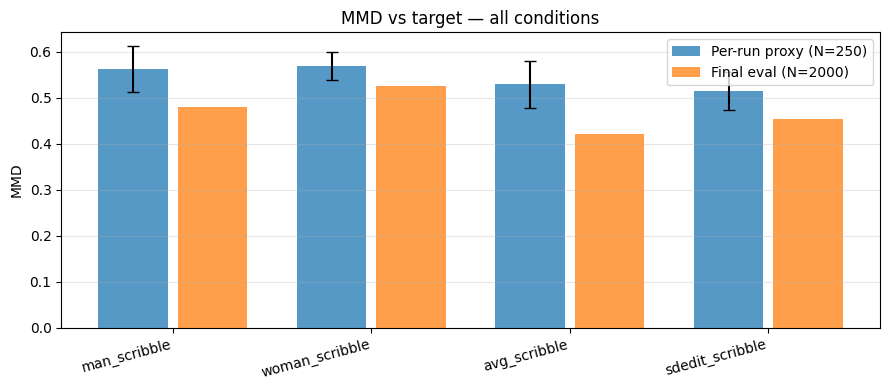

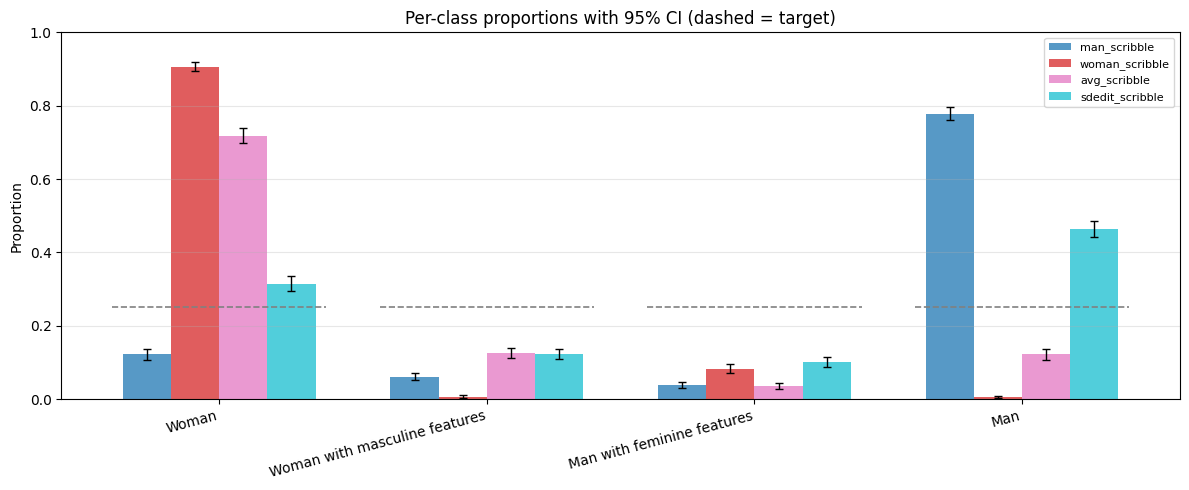

In [12]:
# ── MMD bar chart
means = [np.mean([r['mmd'] for r in all_records if r['condition'] == c]) for c in CONDITION_NAMES]
stds  = [np.std( [r['mmd'] for r in all_records if r['condition'] == c]) for c in CONDITION_NAMES]
final_mmds = [final_results[c]['mmd'] for c in CONDITION_NAMES]

x = np.arange(len(CONDITION_NAMES))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 0.2, means,      0.35, yerr=stds, capsize=4, alpha=0.75, label=f'Per-run proxy (N={N_COND})')
ax.bar(x + 0.2, final_mmds, 0.35, alpha=0.75, label=f'Final eval (N={N_FINAL})')
ax.set_xticks(x); ax.set_xticklabels(CONDITION_NAMES, rotation=15, ha='right')
ax.set_ylabel('MMD'); ax.set_title('MMD vs target — all conditions')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); display(fig); plt.close()

# ── Per-class proportion plot with CI and target reference
n_conds = len(CONDITION_NAMES)
n_classes = len(CLASS_LABELS)
x = np.arange(n_classes)
width = 0.18
colors = plt.cm.tab10(np.linspace(0, 1, n_conds))

fig, ax = plt.subplots(figsize=(12, 5))
for i, (cond, color) in enumerate(zip(CONDITION_NAMES, colors)):
    r      = final_results[cond]
    p_hats = np.array(r['proportions'])
    ci_lo  = np.array(r['ci_lo'])
    ci_hi  = np.array(r['ci_hi'])
    offset = (i - n_conds / 2 + 0.5) * width
    ax.bar(x + offset, p_hats, width, color=color, alpha=0.75, label=cond)
    ax.errorbar(x + offset, p_hats,
                yerr=[p_hats - ci_lo, ci_hi - p_hats],
                fmt='none', color='black', capsize=3, linewidth=1)

# Target reference line per class
for j, (label, frac) in enumerate(zip(CLASS_LABELS, CLASS_FRACS)):
    ax.hlines(frac, j - 0.4, j + 0.4, colors='gray', linestyles='--', linewidth=1.2)

ax.set_xticks(x); ax.set_xticklabels(CLASS_LABELS, rotation=15, ha='right')
ax.set_ylabel('Proportion'); ax.set_title('Per-class proportions with 95% CI (dashed = target)')
ax.set_ylim(0, 1); ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); display(fig); plt.close()

## 12. Save results & download

In [13]:
import shutil

with open(os.path.join(SAVE_DIR, 'all_run_records.json'), 'w') as f:
    json.dump(all_records, f, indent=2)

with open(os.path.join(SAVE_DIR, 'final_results.json'), 'w') as f:
    json.dump(final_results, f, indent=2)

print(f'Results saved to {SAVE_DIR}')

zip_path = '/content/scribble_runs_backup'
shutil.make_archive(zip_path, 'zip', SAVE_DIR)
print(f'Archive: {zip_path}.zip')

from google.colab import files
files.download(f'{zip_path}.zip')

Results saved to /content/scribble_runs
Archive: /content/scribble_runs_backup.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>